# 05 — TCOCNN v3 optimieren und mit Plain/V1 vergleichen

Die Hyperparameteroptimierung ist hier ausdrücklich Teil des Versuchs. Entscheidend ist anschließend der faire Vergleich des besten v3 mit dem Plain/V1-TCOCNN: Fehler, Parameterzahl und eingesparte Parameter.


Verwendete Schicht/Subsensor: 0
Rohdatenquelle: \\ROBNEXUS\Home\GIT\TCOCNN_PY\Data\fullData.mat
Input roh: (1090, 1, 1440, 1) ; Output acetone: (1090,)


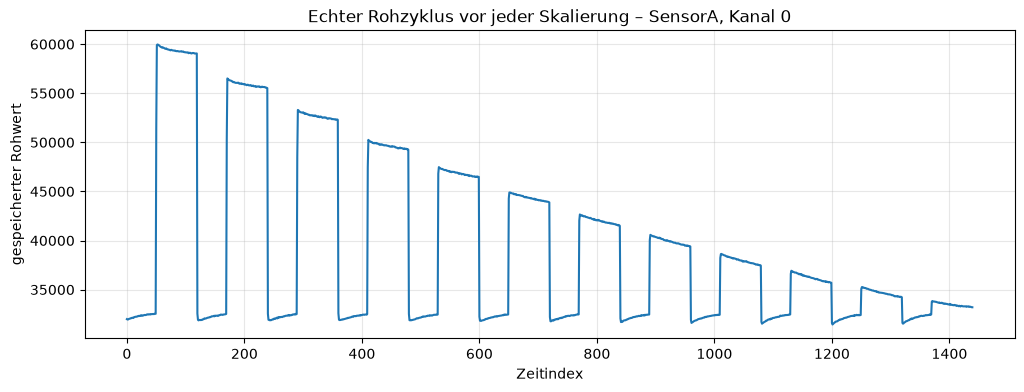

Device: cuda


In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p/'Networks'/'TCOCNNv3.py').exists())
for folder in ['Networks','Evaluation Seminar/Day_02','Evaluation Seminar/Day_03','Evaluation Seminar/Day_04']:
    sys.path.insert(0,str(ROOT/folder))
import numpy as np
import matplotlib.pyplot as plt
from day3_utils import plot_comparison, regression_metrics, show_results

import torch
from skopt import Optimizer
from skopt.space import Categorical, Real
from TCOCNNv3 import TCOCNNv3Class
from day3_utils import prepare_model_data, train_experiment
splits,scaler=prepare_model_data('acetone')

# Nur Schicht/Subsensor 0 verwenden.
# 0:1 erhält die Sensor-Dimension, was für das CNN wichtig ist.
SUBSENSOR = 0
for split_name in splits:
    splits[split_name]['X'] = splits[split_name]['X'][:, SUBSENSOR:SUBSENSOR+1, :, :]
    splits[split_name]['X_z'] = splits[split_name]['X_z'][:, SUBSENSOR:SUBSENSOR+1, :, :]

print('Verwendete Schicht/Subsensor:', SUBSENSOR)
print('Rohdatenquelle:',ROOT/'Data'/'fullData.mat')
print('Input roh:',splits['train']['X'].shape,'; Output acetone:',splits['train']['y'].shape)
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(splits['train']['X'][0,0,:,0])
ax.set(title='Echter Rohzyklus vor jeder Skalierung – SensorA, Kanal 0',xlabel='Zeitindex',ylabel='gespeicherter Rohwert')
ax.grid(True,alpha=.3); plt.show()
EPOCHS=100; SEARCH_TRIALS=24; SEED=42
base=dict(n_filter=32,section_depth=3,kernel=9,stride=4,num_neurons=128,
          drop_out=.15,initial_learning_rate=5e-4,batch_size=64,
          convs_per_block=2,channel_growth=16,residual=True)
rows=[]; predictions={}; histories={}; best_v3=None; best_score=np.inf
print('Device:', 'cuda' if torch.cuda.is_available() else 'cpu')


## Architecture knobs

`section_depth` counts convolution/pooling blocks; `convs_per_block` controls depth within a block.
`n_filter` is the initial width and `channel_growth` adds channels in later blocks. `stride` is the
pooling factor in v3, while its convolutions use stride one. `residual` enables shortcuts.
The dense width follows global pooling, so parameter count is not directly comparable to the flattened
head of the plain architecture. We report it alongside RMSE and runtime.

In [2]:
def run_trial(label,params,v3=True):
    global best_v3,best_score
    model,metadata=train_experiment(splits,params,epochs=EPOCHS,seed=SEED,
                                    model_class=TCOCNNv3Class if v3 else None)
    prediction=model.predict(splits['val']['X_z']).ravel()*scaler['y_std']+scaler['y_mean']
    metrics=regression_metrics(splits['val']['y'],prediction)
    row={'trial':label,**metadata,**metrics,**params}; rows.append(row)
    predictions[label]=prediction; histories[label]=model.history.history
    if v3 and metrics['RMSE_ppb']<best_score:
        best_score=metrics['RMSE_ppb']; best_v3=model
    print(label,'validation RMSE:',round(metrics['RMSE_ppb'],3),flush=True)
    return metrics['RMSE_ppb']
plain={k:v for k,v in base.items() if k not in ['convs_per_block','channel_growth','residual']}
plain['num_neurons']=256
run_trial('Plain reference',plain,v3=False)
run_trial('v3 without residual',{**base,'residual':False})
run_trial('v3 with residual',base)

Epoch 1/100: train=12.5684, val=0.8286
Epoch 10/100: train=0.7940, val=0.8394
Epoch 20/100: train=0.8353, val=0.7628
Epoch 30/100: train=0.7165, val=0.5662
Epoch 40/100: train=0.7048, val=0.5570
Epoch 50/100: train=0.6397, val=0.6529
Epoch 60/100: train=0.6615, val=0.9614
Epoch 70/100: train=0.5995, val=0.6022
Epoch 80/100: train=0.6017, val=0.4377
Epoch 90/100: train=0.5595, val=0.4437
Epoch 100/100: train=0.5427, val=0.4079
Plain reference validation RMSE: 27.748
Epoch 1/100: train=0.8706, val=0.8091
Epoch 10/100: train=0.6859, val=0.8776
Epoch 20/100: train=0.6079, val=1.2334
Epoch 30/100: train=0.6061, val=0.9488
Epoch 40/100: train=0.5564, val=1.6051
Epoch 50/100: train=0.3714, val=1.1190
Epoch 60/100: train=0.3203, val=7.5331
Epoch 70/100: train=0.2414, val=2.7608
Epoch 80/100: train=0.2185, val=1.3193
Epoch 90/100: train=0.2271, val=3.4751
Epoch 100/100: train=0.1782, val=0.8411
v3 without residual validation RMSE: 23.944
Epoch 1/100: train=1.2038, val=0.8356
Epoch 10/100: train

23.547021451518688

In [ ]:
dimensions=[Categorical([24,32,48,64],name='n_filter'),Categorical([2,3,4],name='section_depth'),
            Categorical([1,2,3],name='convs_per_block'),Categorical([0,16,32],name='channel_growth'),Categorical([5,9,15],name='kernel'),
            Categorical([2,4],name='stride'),Categorical([128,256],name='num_neurons'),
            Real(0.,.3,name='drop_out'),Real(1e-6,3e-4,prior='log-uniform',name='initial_learning_rate')]
optimizer=Optimizer(dimensions,n_initial_points=6,random_state=SEED)
for trial in range(1,SEARCH_TRIALS+1):
    values=optimizer.ask()
    sample={dimension.name:value for dimension,value in zip(dimensions,values)}
    score=run_trial(f'v3 search {trial}',{**base,**sample})
    optimizer.tell(values,score)
show_results([{k:row[k] for k in ['trial','RMSE_ppb','R2','best_epoch','parameters','seconds']} for row in rows])
show_results([{'trial':row['trial'], 'filters':row['n_filter'], 'blocks':row['section_depth'],
               'convs_per_block':row.get('convs_per_block','-'), 'channel_growth':row.get('channel_growth','-'),
               'residual':row.get('residual','-'), 'dropout':row['drop_out'],
               'kernel':row['kernel'],'pool':row['stride'],'dense':row['num_neurons'],
               'learning_rate':f"{row['initial_learning_rate']:.2e}"} for row in rows])

Epoch 1/100: train=0.8573, val=0.7947
Epoch 10/100: train=0.7065, val=0.9564
Epoch 20/100: train=0.7010, val=1.0890
Epoch 30/100: train=0.7422, val=0.6902
Epoch 40/100: train=0.6500, val=0.5700
Epoch 50/100: train=0.6763, val=1.2949
Epoch 60/100: train=0.6230, val=0.6068
Epoch 70/100: train=0.5864, val=0.4444
Epoch 80/100: train=0.5472, val=0.8591
Epoch 90/100: train=0.5072, val=0.5201
Epoch 100/100: train=0.4770, val=0.7316
v3 search 1 validation RMSE: 27.348
Epoch 1/100: train=1.0154, val=0.8291
Epoch 10/100: train=0.7518, val=0.8204
Epoch 20/100: train=0.7139, val=0.9272
Epoch 30/100: train=0.6837, val=1.3337
Epoch 40/100: train=0.6866, val=1.2069
Epoch 50/100: train=0.6198, val=1.0622
Epoch 60/100: train=0.6179, val=0.4466
Epoch 70/100: train=0.5265, val=1.1807
Epoch 80/100: train=0.4980, val=1.1080
Epoch 90/100: train=0.4970, val=0.5674
Epoch 100/100: train=0.4778, val=0.3976
v3 search 2 validation RMSE: 27.278
Epoch 1/100: train=1.0049, val=0.9571
Epoch 10/100: train=0.7051, val=

y:\GIT\TCOCNN_PY\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(32), np.int64(3), np.int64(3), np.int64(32), np.int64(15), np.int64(2), np.int64(256), 0.0, 0.0001] before, using random point [24, 2, 1, 16, 15, 2, 256, 0.07719879433665894, 0.0016668971652770755]
  warnings.warn(


Epoch 10/100: train=0.7485, val=1.0949
Epoch 20/100: train=0.7283, val=0.8881
Epoch 30/100: train=0.7233, val=0.7264
Epoch 40/100: train=0.7082, val=0.8793
Epoch 50/100: train=0.7152, val=0.7100
Epoch 60/100: train=0.7265, val=1.4207
Epoch 70/100: train=0.7099, val=0.5287
Epoch 80/100: train=0.6923, val=1.0128
Epoch 90/100: train=0.7075, val=0.5660
Epoch 100/100: train=0.7000, val=0.5314
v3 search 17 validation RMSE: 31.734


y:\GIT\TCOCNN_PY\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(32), np.int64(3), np.int64(3), np.int64(32), np.int64(15), np.int64(2), np.int64(256), 0.0, 0.0001] before, using random point [24, 2, 3, 16, 9, 4, 256, 0.1435803240079604, 0.0002712452588346983]
  warnings.warn(


Epoch 1/100: train=0.9110, val=0.8097
Epoch 10/100: train=0.6909, val=0.8209
Epoch 20/100: train=0.7026, val=0.5565
Epoch 30/100: train=0.6380, val=1.3742
Epoch 40/100: train=0.7006, val=1.1600
Epoch 50/100: train=0.5723, val=0.4800
Epoch 60/100: train=0.5636, val=1.3405
Epoch 70/100: train=0.4957, val=0.4508
Epoch 80/100: train=0.4469, val=0.3922
Epoch 90/100: train=0.3804, val=1.5592
Epoch 100/100: train=0.3543, val=0.2915
v3 search 18 validation RMSE: 23.553


y:\GIT\TCOCNN_PY\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(32), np.int64(3), np.int64(3), np.int64(32), np.int64(15), np.int64(2), np.int64(256), 0.0, 0.0001] before, using random point [32, 2, 3, 16, 5, 2, 256, 0.07460635416312006, 0.00010123478306937608]
  warnings.warn(


Epoch 1/100: train=0.9787, val=0.8238
Epoch 10/100: train=0.7050, val=0.8120
Epoch 20/100: train=0.6885, val=0.8109
Epoch 30/100: train=0.6844, val=0.6249
Epoch 40/100: train=0.6857, val=0.5312
Epoch 50/100: train=0.6658, val=0.5386
Epoch 60/100: train=0.6792, val=0.5105
Epoch 70/100: train=0.6736, val=0.5089
Epoch 80/100: train=0.6704, val=0.5056
Epoch 90/100: train=0.6558, val=0.5114
Epoch 100/100: train=0.6569, val=0.5071
v3 search 19 validation RMSE: 30.894
Epoch 1/100: train=0.8323, val=0.8072
Epoch 10/100: train=0.6513, val=0.8749
Epoch 20/100: train=0.5487, val=0.9554
Epoch 30/100: train=0.2735, val=1.4434
Epoch 40/100: train=0.2549, val=17.0977
Epoch 50/100: train=0.2863, val=35.8738
Epoch 60/100: train=0.1814, val=5.3685
Epoch 70/100: train=0.1622, val=1.4490
Epoch 80/100: train=0.1894, val=3.2853
Epoch 90/100: train=0.1431, val=1.8952
Epoch 100/100: train=0.1347, val=0.5609
v3 search 20 validation RMSE: 17.197
Epoch 1/100: train=1.5198, val=0.8484
Epoch 10/100: train=0.8864, 

trial,RMSE_ppb,R2,best_epoch,parameters,seconds
Plain reference,27.748,0.489,99,2266017,13.323
v3 without residual,23.944,0.620,67,117889,13.307
v3 with residual,23.547,0.632,92,122961,15.888
v3 search 1,27.348,0.504,96,252993,27.174
v3 search 2,27.278,0.507,99,132897,17.593
v3 search 3,22.609,0.661,95,47417,13.241
v3 search 4,17.720,0.792,87,756225,39.348
v3 search 5,32.347,0.306,95,21585,10.151
v3 search 6,30.689,0.375,91,91169,12.731
v3 search 7,18.887,0.763,77,756225,39.400


trial,filters,blocks,convs_per_block,channel_growth,residual,dropout,kernel,pool,dense,learning_rate
Plain reference,32,3,-,-,-,0.150,9,4,256,5.00e-04
v3 without residual,32,3,2,16,False,0.150,9,4,128,5.00e-04
v3 with residual,32,3,2,16,True,0.150,9,4,128,5.00e-04
v3 search 1,64,2,3,16,True,0.100,9,2,128,1.63e-04
v3 search 2,48,2,3,32,True,0.183,5,4,256,1.02e-04
v3 search 3,24,3,2,0,True,0.186,15,2,128,3.67e-04
v3 search 4,64,3,3,32,True,0.169,9,2,256,3.71e-04
v3 search 5,24,2,1,32,True,0.117,9,4,128,1.86e-04
v3 search 6,64,3,1,16,True,0.119,5,4,128,2.34e-03
v3 search 7,64,3,3,32,True,0.024,9,2,256,4.05e-04


## Validation comparisons

Compare the controlled residual pair before interpreting the search winner. Common scatter limits
show calibration bias. The parameter/RMSE scatter shows that more parameters need not improve accuracy.
Twenty-four Bayesian trials are an instructional budget, not evidence that one architecture is universally best.

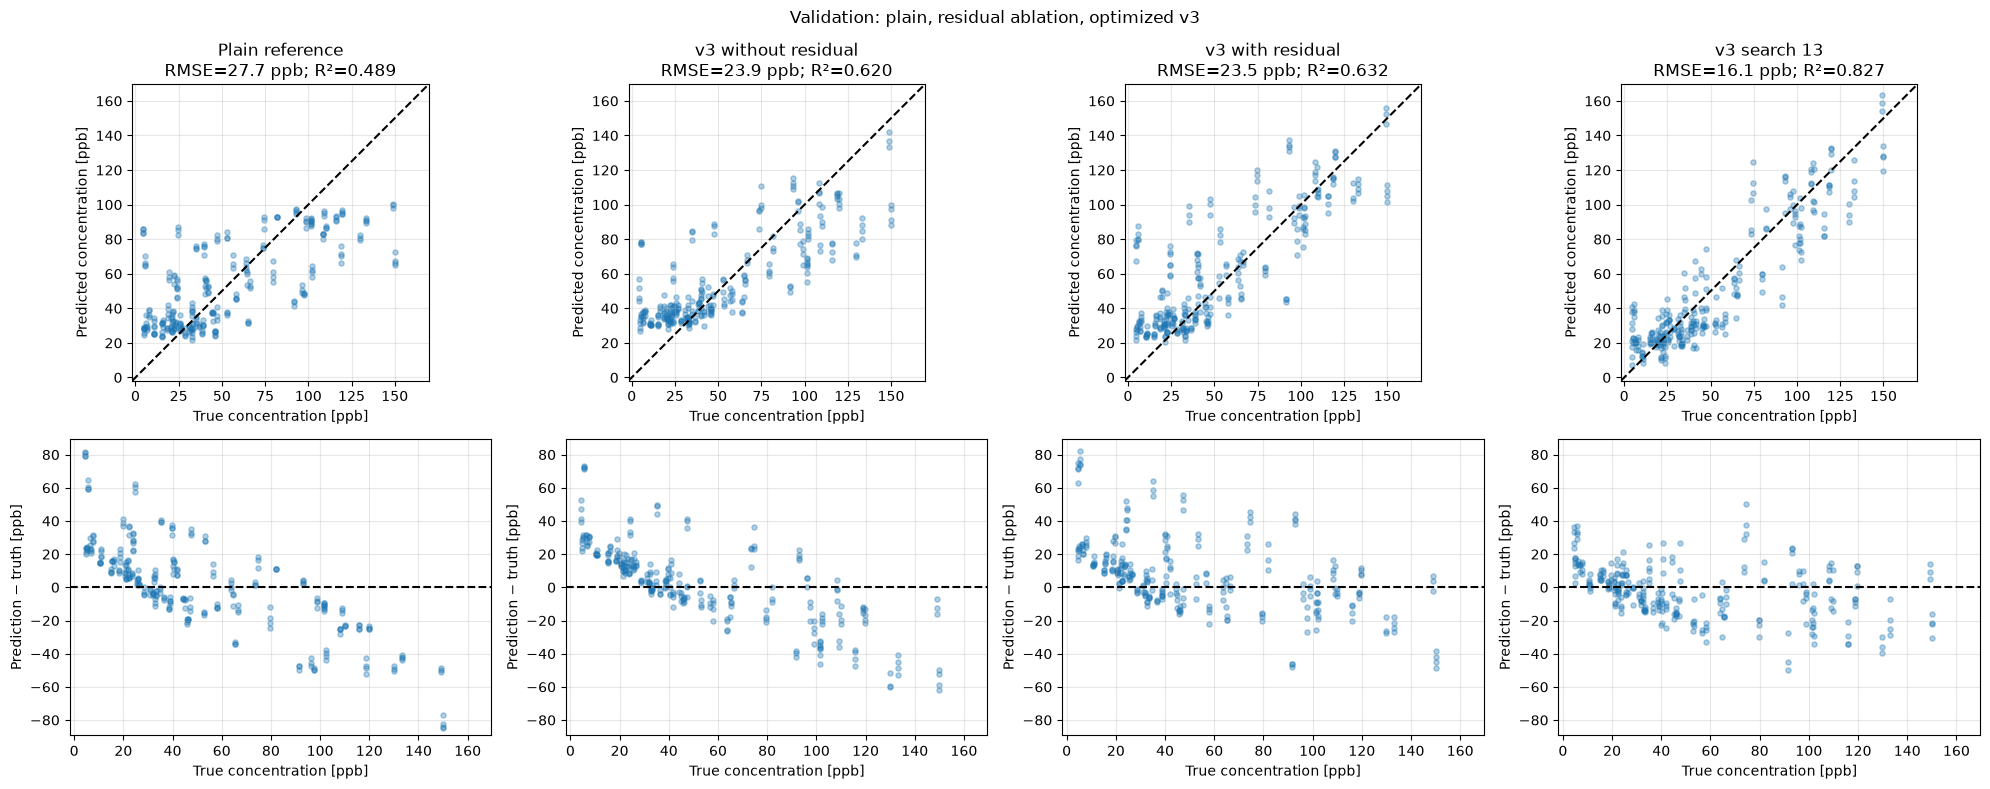

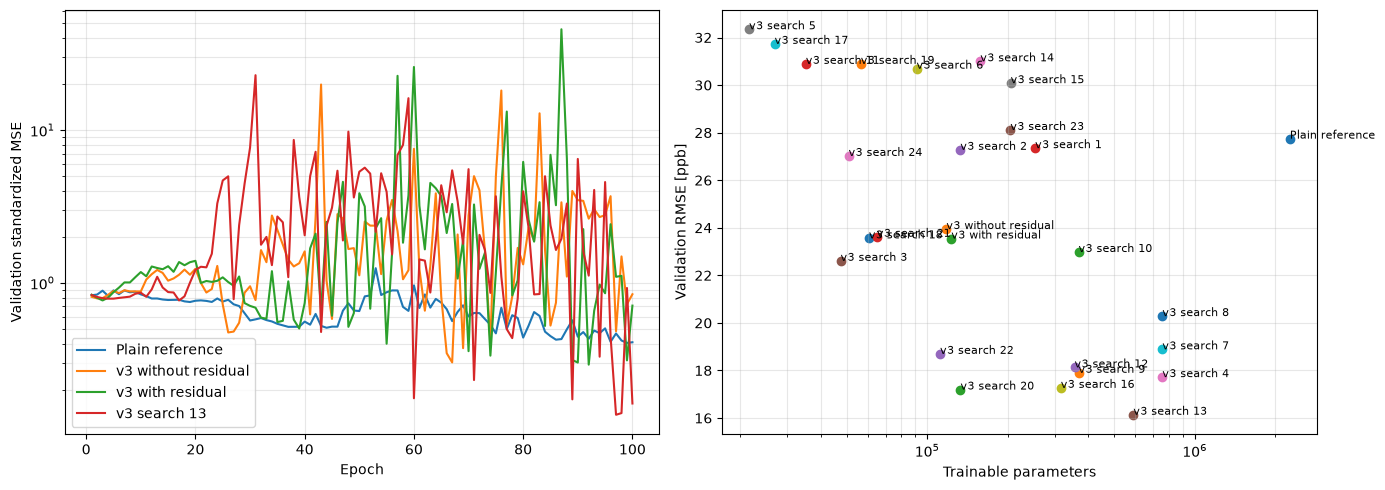

Vergleich,Parameter,RMSE_ppb,eingesparte_Parameter,Ersparnis_Prozent
Plain/V1 TCOCNN,2266017,27.748,0,0.000
bestes TCOCNN v3,589057,16.137,1676960,74.005


Bestes v3 spart 1,676,960 Parameter = 74.0% gegenüber Plain/V1.


In [4]:
best_label=min((row for row in rows if row['trial']!='Plain reference'),key=lambda row:row['RMSE_ppb'])['trial']
labels=list(dict.fromkeys(['Plain reference','v3 without residual','v3 with residual',best_label]))
plot_comparison(splits['val']['y'],{label:predictions[label] for label in labels},'Validation: plain, residual ablation, optimized v3')
fig,axes=plt.subplots(1,2,figsize=(14,5))
for label in labels:
    history=histories[label]
    axes[0].plot(np.arange(1,EPOCHS+1),history['val_loss'],label=label)
axes[0].set(xlabel='Epoch',ylabel='Validation standardized MSE',yscale='log'); axes[0].legend()
for row in rows:
    axes[1].scatter(row['parameters'],row['RMSE_ppb'])
    axes[1].annotate(row['trial'],(row['parameters'],row['RMSE_ppb']),fontsize=8)
axes[1].set(xscale='log',xlabel='Trainable parameters',ylabel='Validation RMSE [ppb]')
for ax in axes: ax.grid(True,which='both',alpha=.3)
plt.tight_layout(); plt.show()
plain_row=next(row for row in rows if row['trial']=='Plain reference')
best_row=min((row for row in rows if row['trial']!='Plain reference'),key=lambda row:row['RMSE_ppb'])
saved=plain_row['parameters']-best_row['parameters']
show_results([{'Vergleich':'Plain/V1 TCOCNN','Parameter':plain_row['parameters'],'RMSE_ppb':plain_row['RMSE_ppb'],
               'eingesparte_Parameter':0,'Ersparnis_Prozent':0.0},
              {'Vergleich':'bestes TCOCNN v3','Parameter':best_row['parameters'],'RMSE_ppb':best_row['RMSE_ppb'],
               'eingesparte_Parameter':saved,'Ersparnis_Prozent':100*saved/plain_row['parameters']}])
print(f"Bestes v3 spart {saved:,} Parameter = {100*saved/plain_row['parameters']:.1f}% gegenüber Plain/V1.")


## Freeze the v3 winner and evaluate once

The regular test and extrapolation test have not entered the search. Report both even if extrapolation
is poor. GPU operations may vary slightly between runs despite fixed initialization seeds.

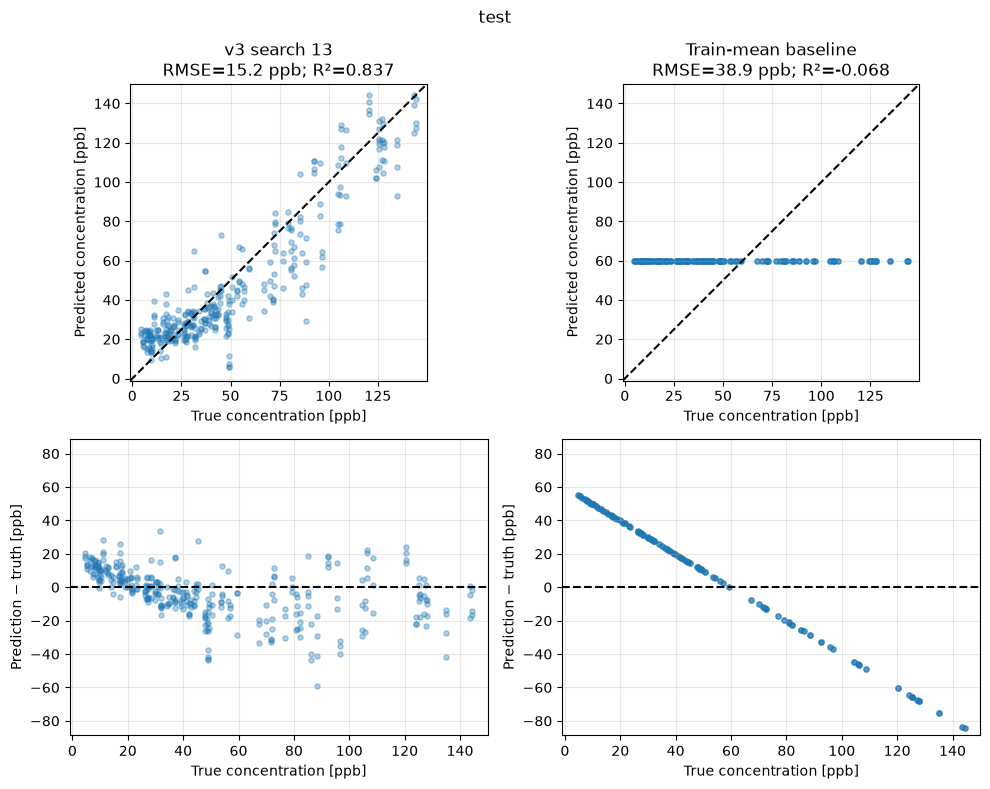

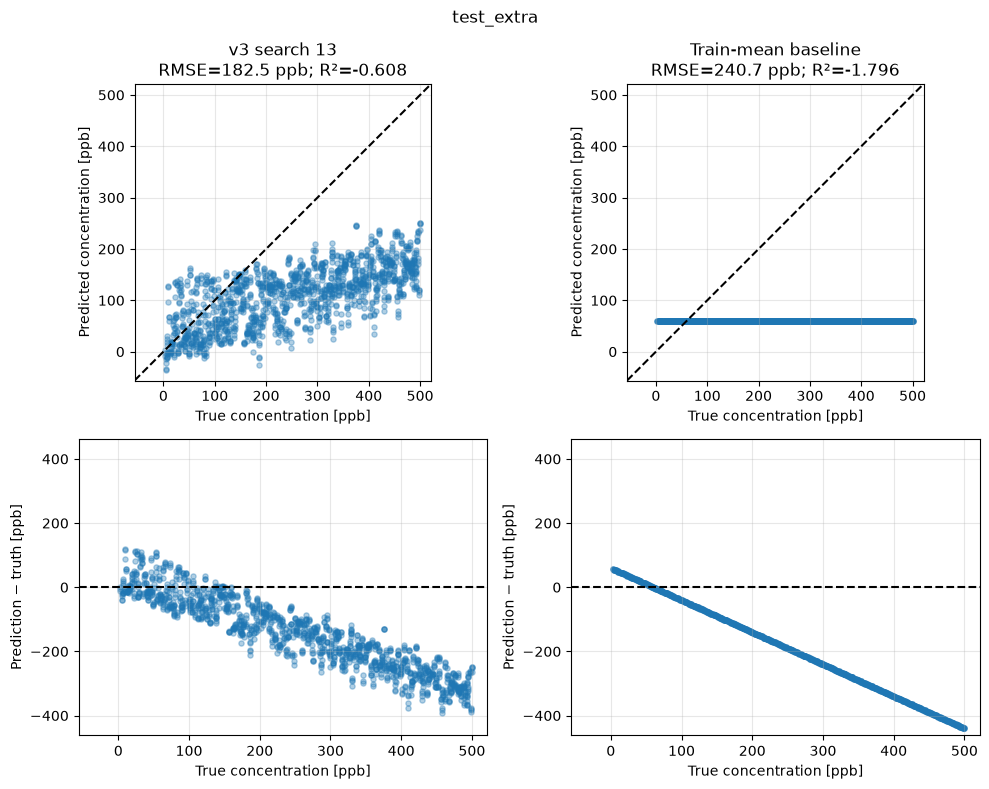

split,RMSE_ppb,MAE_ppb,R2,bias_ppb
test,15.172,11.773,0.837,-3.285
test_extra,182.507,151.942,-0.608,-143.826


In [5]:
final=[]
for name in ['test','test_extra']:
    truth=splits[name]['y']
    pred=best_v3.predict(splits[name]['X_z']).ravel()*scaler['y_std']+scaler['y_mean']
    plot_comparison(truth,{best_label:pred,'Train-mean baseline':np.full_like(truth,scaler['y_mean'])},name)
    final.append({'split':name,**regression_metrics(truth,pred)})
show_results(final)
